In [1]:
import torch
import matplotlib.pyplot as plt

from IPython.display import display
from torch.optim import AdamW
from tqdm.auto import tqdm
from transformers import GPT2Config, GPT2LMHeadModel

from tokenizer import DigitTokenizer
from data_stream import MultiplicationDataStream

In [2]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

batch_size = 100
max_seq_len = 32

d_model = 512
num_layers = 12
num_heads = 4
dropout = 0.1

learning_rate = 1e-4
weight_decay = 0.1

validation_steps = 20
validation_interval = 100
plot_interval = 100

use_bf16 = (
    device.type == "cuda"
    and torch.cuda.is_bf16_supported()
)

torch.set_float32_matmul_precision(
    "high"
)

print("Device:", device)
print("BF16:", use_bf16)

Device: cuda
BF16: True


In [3]:
tokenizer = DigitTokenizer()

data_stream = MultiplicationDataStream(
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_seq_len=max_seq_len,
    initial_max=20.0,
    growth_rate=0.0001,
    beta_alpha=2.0,
    beta_beta=5.0,
    rehearsal_fraction=0.9,
    rehearsal_max=20,
    max_operand_multiple=3,
    seed=42,
)

pad_id = tokenizer.char_to_int["<pad>"]
eos_id = tokenizer.char_to_int["<eos>"]
mul_id = tokenizer.char_to_int["*"]
mod_id = tokenizer.char_to_int["%"]
eq_id = tokenizer.char_to_int["="]

In [4]:
full_seq_len = (
    4 * max_seq_len
    + 3
)

config = GPT2Config(
    vocab_size=tokenizer.vocab_size,
    n_positions=full_seq_len,
    n_ctx=full_seq_len,
    n_embd=d_model,
    n_layer=num_layers,
    n_head=num_heads,
    resid_pdrop=dropout,
    embd_pdrop=dropout,
    attn_pdrop=dropout,
    pad_token_id=pad_id,
    eos_token_id=eos_id,
    use_cache=False,
    bos_token_id=None
)

model = GPT2LMHeadModel(
    config
).to(device)

optimizer = AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    f"Parameters: {parameter_count:,}"
)

Parameters: 37,904,896


In [5]:
def prepare_baseline_batch(
    batch: torch.Tensor,
) -> tuple[
    torch.Tensor,
    torch.Tensor,
    torch.Tensor,
]:
    sequences = []

    for sample in batch:
        a, b, p, target = sample

        a_tokens = a[
            a != pad_id
        ].tolist()

        b_tokens = b[
            b != pad_id
        ].tolist()

        p_tokens = p[
            p != pad_id
        ].tolist()

        target_tokens = target[
            target != pad_id
        ].tolist()

        sequence = (
            a_tokens
            + [mul_id]
            + b_tokens
            + [mod_id]
            + p_tokens
            + [eq_id]
            + target_tokens
        )

        if len(sequence) > full_seq_len:
            raise ValueError(
                f"Sequence requires {len(sequence)} tokens, "
                f"but full_seq_len is {full_seq_len}."
            )

        sequence += [
            pad_id
        ] * (
            full_seq_len
            - len(sequence)
        )

        sequences.append(
            sequence
        )

    input_ids = torch.tensor(
        sequences,
        dtype=torch.long,
        device=device,
    )

    attention_mask = (
        input_ids != pad_id
    ).long()

    labels = input_ids.clone()

    eq_positions = (
        input_ids == eq_id
    ).int().argmax(
        dim=1
    )

    positions = torch.arange(
        full_seq_len,
        device=device,
    ).unsqueeze(0)

    prefix_mask = (
        positions
        <= eq_positions.unsqueeze(1)
    )

    labels[
        prefix_mask
    ] = -100

    labels[
        input_ids == pad_id
    ] = -100

    return (
        input_ids,
        attention_mask,
        labels,
    )

In [6]:
sample_batch = data_stream.next_batch()

input_ids, attention_mask, labels = (
    prepare_baseline_batch(
        sample_batch
    )
)

visible_tokens = input_ids[
    0,
    attention_mask[0].bool(),
].tolist()

visible_labels = labels[
    0,
    labels[0] != -100,
].tolist()

print(
    "Full sequence:",
    tokenizer.decode(
        visible_tokens
    ),
)

print(
    "Loss target:",
    tokenizer.decode(
        visible_labels
    ),
)

print(
    "Input shape:",
    input_ids.shape,
)

Full sequence: 7*31%4=3
Loss target: 3
Input shape: torch.Size([100, 131])


In [7]:
@torch.no_grad()
def predict_sample(
    sample: torch.Tensor,
) -> list[int]:
    model.eval()

    a, b, p, _ = sample

    a_tokens = a[
        a != pad_id
    ].tolist()

    b_tokens = b[
        b != pad_id
    ].tolist()

    p_tokens = p[
        p != pad_id
    ].tolist()

    prefix = (
        a_tokens
        + [mul_id]
        + b_tokens
        + [mod_id]
        + p_tokens
        + [eq_id]
    )

    generated = torch.tensor(
        [prefix],
        dtype=torch.long,
        device=device,
    )

    prediction = []

    for _ in range(max_seq_len):
        attention_mask = torch.ones_like(
            generated
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_bf16,
        ):
            outputs = model(
                input_ids=generated,
                attention_mask=attention_mask,
            )

        next_token = outputs.logits[
            0,
            -1,
        ].argmax().item()

        prediction.append(
            next_token
        )

        generated = torch.cat(
            [
                generated,
                torch.tensor(
                    [[next_token]],
                    dtype=torch.long,
                    device=device,
                ),
            ],
            dim=1,
        )

        if next_token == eos_id:
            break

    return prediction


@torch.no_grad()
def validate_model() -> tuple[float, float]:
    model.eval()

    validation_loader = (
        data_stream.create_validation_chunk_loader(
            num_steps=validation_steps,
            lookahead_steps=0,
            batch_size=batch_size,
            seed=10_000,
        )
    )

    total_loss = 0.0
    total_batches = 0

    total_correct = 0
    total_samples = 0

    for batch in validation_loader:
        input_ids, attention_mask, labels = (
            prepare_baseline_batch(
                batch
            )
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_bf16,
        ):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )

        total_loss += outputs.loss.item()
        total_batches += 1

        for sample in batch:
            target = sample[3]

            target_tokens = target[
                target != pad_id
            ].tolist()

            prediction = predict_sample(
                sample
            )

            total_correct += int(
                prediction == target_tokens
            )

            total_samples += 1

    average_loss = (
        total_loss
        / total_batches
    )

    exact_match_accuracy = (
        total_correct
        / total_samples
    )

    return (
        average_loss,
        exact_match_accuracy,
    )

In [8]:
train_step_history = []
train_loss_history = []

validation_step_history = []
validation_loss_history = []
validation_accuracy_history = []

global_step = 0

figure = None
loss_axis = None
accuracy_axis = None
display_handle = None


def update_live_plot() -> None:
    loss_axis.clear()
    accuracy_axis.clear()

    loss_axis.plot(
        train_step_history,
        train_loss_history,
        label="Training loss",
    )

    if validation_loss_history:
        loss_axis.plot(
            validation_step_history,
            validation_loss_history,
            label="Validation loss",
            marker="o",
        )

        accuracy_axis.plot(
            validation_step_history,
            validation_accuracy_history,
            label="Validation accuracy",
            marker="o",
        )

    loss_axis.set_title(
        "Vanilla GPT-2 Baseline"
    )

    loss_axis.set_xlabel(
        "Training step"
    )

    loss_axis.set_ylabel(
        "Cross-entropy loss"
    )

    accuracy_axis.set_ylabel(
        "Exact-match accuracy"
    )

    accuracy_axis.set_ylim(
        0.0,
        1.0,
    )

    loss_axis.legend(
        loc="upper left"
    )

    if validation_accuracy_history:
        accuracy_axis.legend(
            loc="upper right"
        )

    loss_axis.grid()

    figure.tight_layout()

    display_handle.update(
        figure
    )

In [9]:
def train_model(
    steps: int,
) -> None:
    global global_step
    global figure
    global loss_axis
    global accuracy_axis
    global display_handle

    if display_handle is None:
        figure, loss_axis = plt.subplots(
            figsize=(14, 7)
        )

        accuracy_axis = loss_axis.twinx()

        display_handle = display(
            figure,
            display_id=True,
        )

        plt.close(
            figure
        )

    progress_bar = tqdm(
        range(steps),
        desc="Training baseline",
    )

    for _ in progress_bar:
        model.train()

        batch = data_stream.next_batch()

        input_ids, attention_mask, labels = (
            prepare_baseline_batch(
                batch
            )
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_bf16,
        ):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )

            train_loss = outputs.loss

        train_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        global_step += 1

        train_step_history.append(
            global_step
        )

        train_loss_history.append(
            train_loss.item()
        )

        if (
            global_step
            % validation_interval
            == 0
        ):
            (
                validation_loss,
                validation_accuracy,
            ) = validate_model()

            validation_step_history.append(
                global_step
            )

            validation_loss_history.append(
                validation_loss
            )

            validation_accuracy_history.append(
                validation_accuracy
            )

        if (
            global_step
            % plot_interval
            == 0
        ):
            update_live_plot()

        progress_values = {
            "step": global_step,
            "train_loss": (
                f"{train_loss.item():.4f}"
            ),
            "current_max": (
                f"{data_stream.current_max:.2f}"
            ),
        }

        if validation_loss_history:
            progress_values[
                "validation_loss"
            ] = (
                f"{validation_loss_history[-1]:.4f}"
            )

            progress_values[
                "validation_accuracy"
            ] = (
                f"{validation_accuracy_history[-1]:.4f}"
            )

        progress_bar.set_postfix(
            progress_values
        )

    update_live_plot()

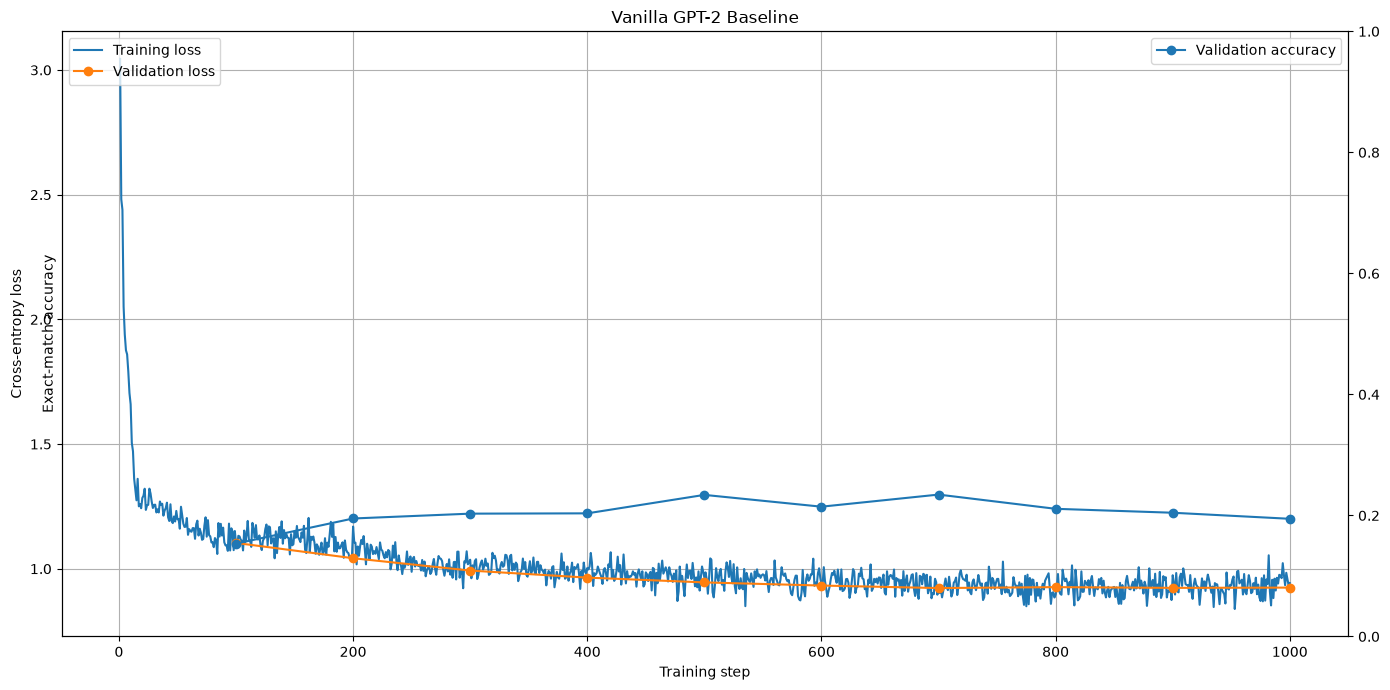

Training baseline:   0%|          | 0/1000 [00:00<?, ?it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


In [10]:
train_model(
    steps=1_000,
)